In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
#Step 1: Load the files
df = pd.read_csv("stat-stop-smok-serv-eng-2025-26-q4.csv")
fin = pd.read_csv("stat-stop-smok-serv-finance-eng-2025-26-q4.csv")

In [3]:
print(df.shape)
print(df.columns.tolist())
df.head()

(110188, 23)
['FinancialYear', 'Quarter', 'OrgType', 'OrgCode', 'OrgName', 'RegionCode', 'RegionName', 'Sex', 'MonitoringCategoryType', 'MonitoringCategory', 'Total referred', 'Recipients', 'Set quit date', 'Quit', 'Not quit', 'Not known', 'Quit CO', 'Unengaged quit', 'Quit (%)', 'Not quit (%)', 'Not known (%)', 'Quit CO (%)', 'Quit CO of quitters (%)']


,FinancialYear,Quarter,OrgType,OrgCode,OrgName,RegionCode,RegionName,Sex,MonitoringCategoryType,MonitoringCategory,...,Quit,Not quit,Not known,Quit CO,Unengaged quit,Quit (%),Not quit (%),Not known (%),Quit CO (%),Quit CO of quitters (%)
0,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,18-34,...,5019.0,2458.0,3110.0,1138.0,:,47.5,23.3,29.4,10.8,22.7
1,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,35-44,...,5930.0,3150.0,3280.0,1228.0,:,48.0,25.5,26.6,9.9,20.7
2,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,45-59,...,11542.0,5804.0,4864.0,2651.0,:,52.0,26.1,21.9,11.9,23.0
3,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,60 and over,...,10281.0,5173.0,3200.0,2518.0,:,55.1,27.7,17.2,13.5,24.5
4,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,All ages,...,32870.0,16648.0,14506.0,7556.0,:,51.4,26.0,22.7,11.8,23.0


In [4]:
#shape of the data 
print(df["OrgType"].unique())
print(df["Quarter"].unique())
print(df["MonitoringCategoryType"].unique())

['National' 'LARegion' 'LA']
[1 2 3 4]
['Age band' 'Ethnicity' 'Ethnicity grouped' 'Sexual orientation'
 'Eligibility to free prescriptions' 'Socio-economic classification'
 'Pharmacotherapy received' 'Intervention type' 'Intervention setting'
 'Swap to stop' 'Pregnant women']


In [5]:
numeric_cols = ["Total referred", "Set quit date", "Quit", "Quit (%)"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].dtypes

Total referred    float64
Set quit date     float64
Quit              float64
Quit (%)          float64
dtype: object

In [6]:
base = df[
    (df["MonitoringCategoryType"] == "Age band") &
    (df["Sex"] == "All persons") &
    (df["MonitoringCategory"] == "All ages")
].copy()

base.shape

(652, 23)

## Build the Surrey vs South East vs England trend

In [7]:
areas = ["Surrey", "South East", "England"]
trend = base[base["OrgName"].isin(areas)][
    ["OrgName", "Quarter", "Total referred", "Set quit date", "Quit", "Quit (%)"]
].sort_values(["OrgName", "Quarter"])

trend

,OrgName,Quarter,Total referred,Set quit date,Quit,Quit (%)
4,England,1,94855.0,63984.0,32870.0,51.4
28,England,2,98017.0,61957.0,32566.0,52.6
52,England,3,96747.0,63585.0,33945.0,53.4
76,England,4,115334.0,75976.0,41681.0,54.9
268,South East,1,14444.0,9711.0,5051.0,52.0
484,South East,2,13231.0,9702.0,5112.0,52.7
700,South East,3,14925.0,9845.0,5151.0,52.3
916,South East,4,17495.0,11468.0,6035.0,52.6
4228,Surrey,1,1566.0,802.0,484.0,60.3
7900,Surrey,2,1013.0,769.0,448.0,58.3


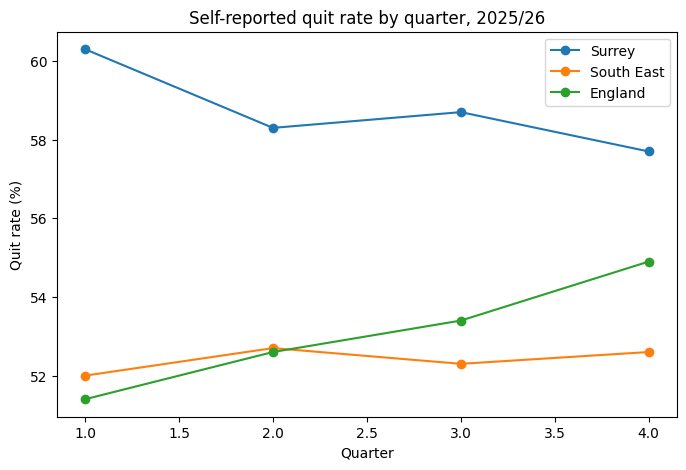

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for org in areas:
    sub = trend[trend["OrgName"] == org]
    ax.plot(sub["Quarter"], sub["Quit (%)"], marker="o", label=org)

ax.set_title("Self-reported quit rate by quarter, 2025/26")
ax.set_xlabel("Quarter")
ax.set_ylabel("Quit rate (%)")
ax.legend()
plt.show()

### Surrey stayed above the South East and England in all four quarters. The gap to England narrowed from about 9 points in Q1 to about 3 points in Q4, because England's rate rose each quarter and Surrey's fell by about 2.6 points. The y-axis starts at 51 percent, so the gaps look larger than they are.

In [9]:
#Build the annual local authority comparison
se_las = base[(base["RegionName"] == "South East") & (base["OrgType"] == "LA")]

annual = se_las.groupby("OrgName").agg(
    quit_dates=("Set quit date", "sum"),
    quits=("Quit", "sum"),
).reset_index()

annual["quit_rate"] = (annual["quits"] / annual["quit_dates"] * 100).round(1)
annual = annual.sort_values("quit_rate", ascending=False)
annual

,OrgName,quit_dates,quits,quit_rate
18,Wokingham,701.0,456.0,65.0
15,West Berkshire,807.0,490.0,60.7
0,Bracknell Forest,1006.0,601.0,59.7
11,Reading,905.0,532.0,58.8
14,Surrey,3228.0,1896.0,58.7
3,East Sussex,2602.0,1511.0,58.1
9,Oxfordshire,1876.0,1082.0,57.7
17,Windsor and Maidenhead,803.0,460.0,57.3
6,Kent,7079.0,3896.0,55.0
4,Hampshire,5247.0,2811.0,53.6


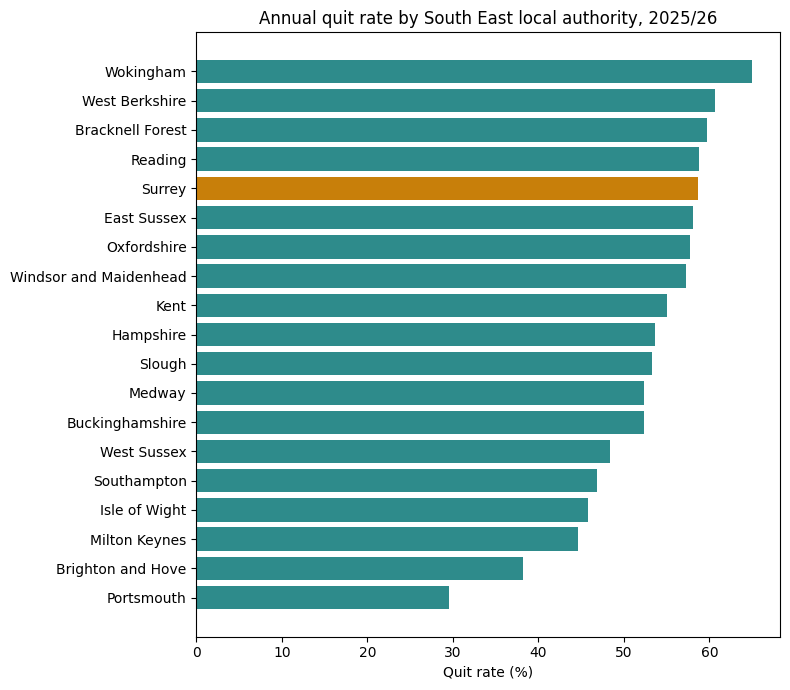

In [10]:
#Plot the local Authority tracking
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#C87F0A" if la == "Surrey" else "#2E8B8B" for la in annual["OrgName"]]
ax.barh(annual["OrgName"], annual["quit_rate"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Quit rate (%)")
ax.set_title("Annual quit rate by South East local authority, 2025/26")
plt.tight_layout()
plt.show()

In [11]:
#Bring in spend and calculate cost per quitter
fin_areas = fin[fin["OrgName"].isin(areas)].copy()
fin_areas["total_spend"] = (
    fin_areas["Total spend on delivery of stop smoking services for the year to date"]
    + fin_areas["Total cost of stop smoking aids for the year to date"]
)

annual_totals = base[base["OrgName"].isin(areas)].groupby("OrgName")["Quit"].sum().reset_index()
cost = annual_totals.merge(fin_areas[["OrgName", "total_spend"]], on="OrgName")
cost["cost_per_quitter"] = (cost["total_spend"] / cost["Quit"]).round(0)
cost

,OrgName,Quit,total_spend,cost_per_quitter
0,England,141062.0,99424791.0,705.0
1,South East,21349.0,15734400.0,737.0
2,Surrey,1896.0,1283464.0,677.0


In [12]:
# Reusable helper: gives one row per category (e.g. one row per
# socio-economic group) with quit rate calculated, for any area
# and any breakdown type in the file.
def annual_by_category(org_name, cat_type):
    sub = df[(df["OrgName"] == org_name)
             & (df["MonitoringCategoryType"] == cat_type)
             & (df["Sex"] == "All persons")]
    g = sub.groupby("MonitoringCategory").agg(
        quit_dates=("Set quit date", "sum"),
        quits=("Quit", "sum"),
    ).reset_index()
    g["quit_rate"] = (g["quits"] / g["quit_dates"] * 100).round(1)
    return g

In [13]:
# This maps directly to the advert's stated priority: "reduce
# health inequalities." Compare West Sussex against England,
# group by group, rather than looking at one blended average.
s_se = annual_by_category("Surrey", "Socio-economic classification")
eng_se = annual_by_category("England", "Socio-economic classification")

se_gap = s_se.merge(eng_se, on="MonitoringCategory", suffixes=("_S", "_Eng"))
se_gap["gap_pts"] = (se_gap["quit_rate_S"] - se_gap["quit_rate_Eng"]).round(1)

# Drop groups with very few quit attempts — a rate built on a
# handful of people is noise, not a finding.
se_gap = se_gap[se_gap["quit_dates_S"] >= 30]
se_gap = se_gap.sort_values("quit_dates_S", ascending=False)

se_gap.to_csv("socioeconomic_quit_rate_gap.csv", index=False)
se_gap[["MonitoringCategory", "quit_dates_S", "quit_rate_S", "quit_rate_Eng", "gap_pts"]]

,MonitoringCategory,quit_dates_S,quit_rate_S,quit_rate_Eng,gap_pts
7,Routine and manual occupations,644.0,63.7,56.6,7.1
3,Managerial and professional occupations,631.0,63.5,56.2,7.3
4,Never worked or unemployed for over 1 year,469.0,53.1,47.8,5.3
9,Unable to code,375.0,56.0,47.3,8.7
6,Retired,352.0,61.6,56.5,5.1
8,Sick/disabled and unable to return to work,326.0,57.1,50.9,6.2
2,Intermediate occupations,256.0,59.0,56.4,2.6
1,Home carers (unpaid),89.0,46.1,53.0,-6.9
0,Full time students,86.0,36.0,46.2,-10.2


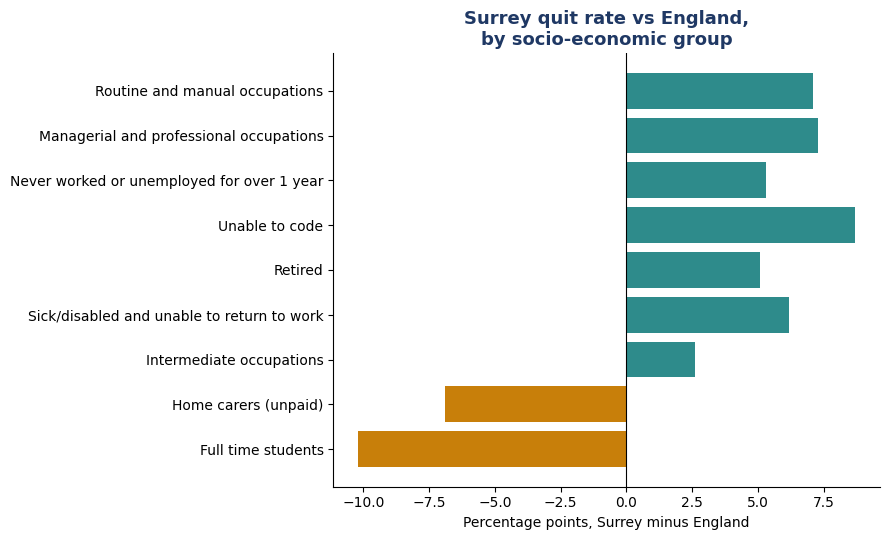

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#C87F0A" if g < 0 else "#2E8B8B" for g in se_gap["gap_pts"]]
ax.barh(se_gap["MonitoringCategory"], se_gap["gap_pts"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)  # zero line marks "level with England"
ax.invert_yaxis()
ax.set_title("Surrey quit rate vs England,\nby socio-economic group",
             fontsize=13, color="#1F3864", weight="bold")
ax.set_xlabel("Percentage points, Surrey minus England")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("socioeconomic_quit_rate_gap.png", dpi=150)
plt.show()

In [15]:
s_it = annual_by_category("Surrey", "Intervention type")
eng_it = annual_by_category("England", "Intervention type")

it_gap = s_it.merge(eng_it, on="MonitoringCategory", suffixes=("_S", "_Eng"))
it_gap["gap_pts"] = (it_gap["quit_rate_S"] - it_gap["quit_rate_Eng"]).round(1)
it_gap = it_gap[it_gap["quit_dates_S"] >= 30]
it_gap = it_gap.sort_values("quit_dates_S", ascending=False)

it_gap[["MonitoringCategory", "quit_dates_S", "quit_rate_S", "quit_rate_Eng", "gap_pts"]]

,MonitoringCategory,quit_dates_S,quit_rate_S,quit_rate_Eng,gap_pts
8,Telephone support,1847.0,65.9,56.5,9.4
5,One-to-one support in person,801.0,52.7,47.7,5.0
2,Digital support by mobile application,561.0,45.1,47.8,-2.7


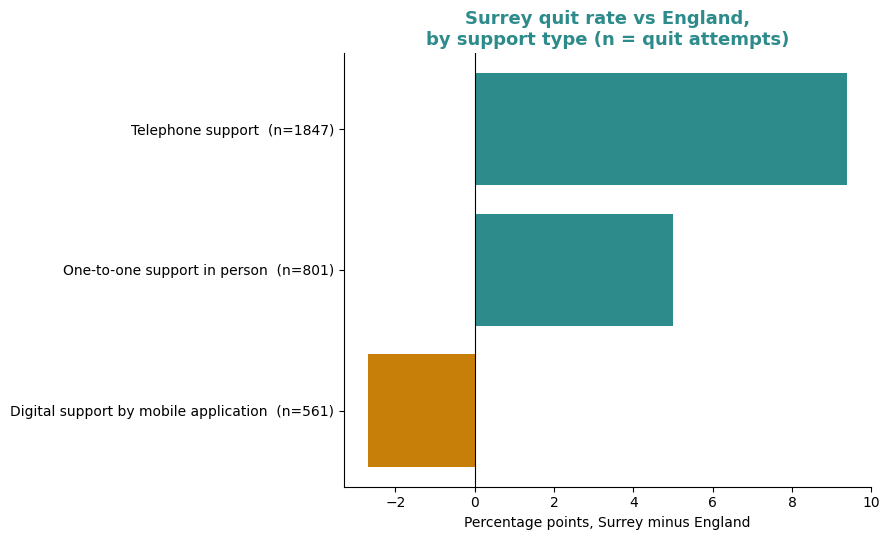

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#C87F0A" if g < 0 else "#2E8B8B" for g in it_gap["gap_pts"]]
labels = [f"{cat}  (n={int(n)})" for cat, n in zip(it_gap["MonitoringCategory"], it_gap["quit_dates_S"])]
ax.barh(labels, it_gap["gap_pts"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("Percentage points, Surrey minus England")
ax.set_title("Surrey quit rate vs England,\nby support type (n = quit attempts)",
             fontsize=13, color="#2E8B8B", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()